# Blood Pressure and Age

**Category:** Data Modeling  
**Dataset:** blood-pressure-usa.csv (100 people, 3 readings each) +
blood-pressure-yanomami.csv (71 people, 1 reading each)  
**Objective:** Fit a linear model of blood pressure vs. age for two very
different populations, compare them, and reason carefully about whether
this proves salt intake causes the difference.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.linear_model import LinearModel

usa = pd.read_csv('../data/blood-pressure-usa.csv')
yanomami = pd.read_csv('../data/blood-pressure-yanomami.csv')

usa.head()

,age,bp1,bp2,bp3
0,46,122,129,122
1,43,113,116,111
2,29,102,107,105
3,12,100,102,102
4,9,112,138,94


In [2]:
yanomami.head()

,age,bp
0,34,99
1,2,79
2,40,97
3,2,101
4,16,107


## 1. Dataset Exploration

Exploring both populations and comparing their age distributions before
building the regression models.

In [3]:
print("=== USA ===")
print("Shape:", usa.shape)
print("Age range:", usa['age'].min(), "-", usa['age'].max())
print("Missing values:", usa.isnull().sum().sum())
print()

print("=== YANOMAMI ===")
print("Shape:", yanomami.shape)
print("Age range:", yanomami['age'].min(), "-", yanomami['age'].max())
print("Missing values:", yanomami.isnull().sum().sum())

=== USA ===
Shape: (100, 4)
Age range: 8 - 57
Missing values: 0

=== YANOMAMI ===
Shape: (71, 2)
Age range: 1 - 60
Missing values: 0


## 2. Feature Engineering: Average the USA Readings

Each USA participant has three blood pressure readings. Averaging them
reduces measurement noise and creates one value per person, matching the
Yanomami dataset for a fair comparison.

In [4]:
usa['bp_avg'] = usa[['bp1', 'bp2', 'bp3']].mean(axis=1)

usa[['age', 'bp1', 'bp2', 'bp3', 'bp_avg']].head()

,age,bp1,bp2,bp3,bp_avg
0,46,122,129,122,124.333333
1,43,113,116,111,113.333333
2,29,102,107,105,104.666667
3,12,100,102,102,101.333333
4,9,112,138,94,114.666667


## 3. Fit the USA Model

Using the course's LinearModel class to fit blood pressure vs. age.

In [ ]:
usa_model = LinearModel(model_name='USA')
usa_model.fit(usa['age'], usa['bp_avg'])
usa_model.print_model_info()

LinearModel(USA):
Slope: 0.7414760958354747
Intercept: 93.36952968206755
R-squared: 0.4720150175059835


## 4. Fit the Yanomami Model

In [7]:
yanomami_model = LinearModel(model_name='Yanomami')
yanomami_model.fit(yanomami['age'], yanomami['bp'])
yanomami_model.print_model_info()

LinearModel(Yanomami):
Slope: -0.004198440057105069
Intercept: 95.47465789198789
R-squared: 5.3201360953769594e-05


## 5. Visualize Both Models Together

Plotting both fitted models on the same axes to enable a direct and fair
comparison between the two populations.

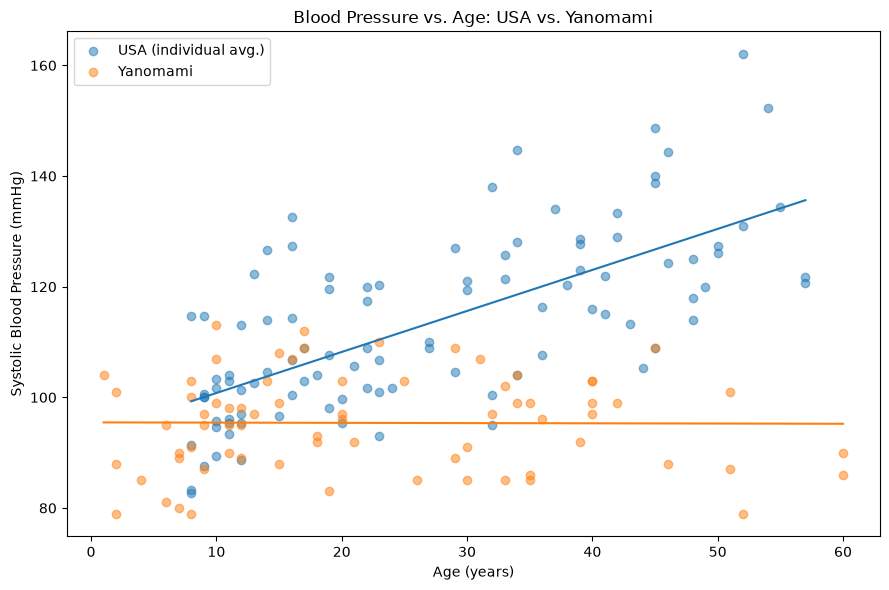

Chart Saved.


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    usa['age'],
    usa['bp_avg'],
    alpha=0.5,
    color='C0',
    label='USA (individual avg.)'
)

ax.scatter(
    yanomami['age'],
    yanomami['bp'],
    alpha=0.5,
    color='C1',
    label='Yanomami'
)

usa_model.plot_model(
    usa['age'].min(),
    usa['age'].max(),
    color='C0'
)

yanomami_model.plot_model(
    yanomami['age'].min(), 
    yanomami['age'].max(),
    color='C1'
)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Systolic Blood Pressure (mmHg)')
ax.set_title('Blood Pressure vs. Age: USA vs. Yanomami')
ax.legend()

plt.tight_layout()
plt.savefig('../images/plots/bp_vs_age_both_populations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 6. Confounding Variables Discussion

- The results show a strong **correlation** between population and blood pressure trends with age.

- This comparison **does not establish causation**. The two populations differ in many ways besides salt intake, including physical activity, body weight, overall diet, genetics, stress, and healthcare access.

- Demonstrating causation would require larger observational studies that control for these factors or carefully designed controlled experiments.

- **Conclusion:** The findings are consistent with the salt-intake hypothesis, but this dataset alone cannot prove that salt intake causes the observed differences.

## 7. My Own Question: What Other Factors Might Explain the Difference?

Identifying other plausible factors that could influence blood pressure
beyond salt intake, emphasizing the role of confounding variables.

Possible alternative explanations include:

- **Physical activity:** The Yanomami likely have much higher daily physical activity, which is independently associated with lower blood pressure.

- **Body weight:** Differences in obesity and body weight may contribute to blood pressure differences between the populations.

- **Genetics:** Genetic differences could influence blood pressure independently of salt intake.

- **Stress and lifestyle:** Differences in stress levels and overall lifestyle may also affect blood pressure.

Since these variables are not included in the dataset, none of these explanations can be confirmed or ruled out. Identifying them highlights the importance of considering potential confounding variables before drawing causal conclusions.

## 8. Key Insights

- Blood pressure increased with age in the **USA** population (slope ≈ **0.74 mmHg/year**, **R² ≈ 0.47**), indicating a moderate positive relationship.

- The **Yanomami** population showed almost no relationship between age and blood pressure (slope ≈ **−0.004**, **R² ≈ 0.0001**).

- The observed difference is consistent with the **salt-intake hypothesis**, but this dataset alone cannot establish causation because other potential confounding variables were not controlled.

- Averaging the three blood pressure readings for each USA participant ensured one observation per person, satisfying the assumption of independent observations.

- Comparing the two fitted models on the same scale clearly highlighted the contrasting age-related blood pressure trends between the populations.